<a href="https://colab.research.google.com/github/PreethamHD/DP-MMFL/blob/main/notebooks/04_image_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q redivis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.9/75.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 820.4/820.4 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.3/408.3 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.1 MB/s eta 0:00:00


In [12]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [13]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/content/drive/MyDrive/DP-MMFL")

MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "chexpert_plus_manifest.parquet"
)

manifest = pd.read_parquet(MANIFEST_PATH)

print("Manifest loaded successfully.")
print("Shape:", manifest.shape)

Manifest loaded successfully.
Shape: (223462, 54)


In [2]:
import redivis

print("Redivis imported successfully.")

Redivis imported successfully.


In [3]:
import redivis

table = redivis.table(
    "aimi.chexpert_plus:5yyj:v1_0.png_train:s6cj"
)

print("Table reference created successfully.")

Table reference created successfully.


In [4]:
file = table.file(
    "patient00001/study1/view1_frontal.png"
)

print("File reference created successfully.")
print(file.properties)

Please visit the URL below to authenticate with your Redivis account:
https://redivis.com/oauth/authorize?user_code=27a9da363716c35445adb7e14426f920
File reference created successfully.
{'file_id': 's6cj-f5e10m11h.4MafEl-RrYhHLi2oPR7rSQ', 'file_name': 'patient00001/study1/view1_frontal.png', 'size': 6390005, 'added_at': datetime.datetime(2026, 2, 16, 4, 43, 43, 792000), 'md5_hash': 'v8f4oWG8t7KpTWsXeQn3Ng==', '__partitionIndex': datetime.datetime(1960, 1, 1, 0, 0), '__uid': None}


In [6]:
from PIL import Image
from io import BytesIO

data = file.read(as_text=False)

print("Downloaded bytes:", len(data))

image = Image.open(BytesIO(data))
image.load()

print("Image format:", image.format)
print("Image mode:", image.mode)
print("Image size:", image.size)

Downloaded bytes: 6390005
Image format: PNG
Image mode: L
Image size: (3408, 2800)


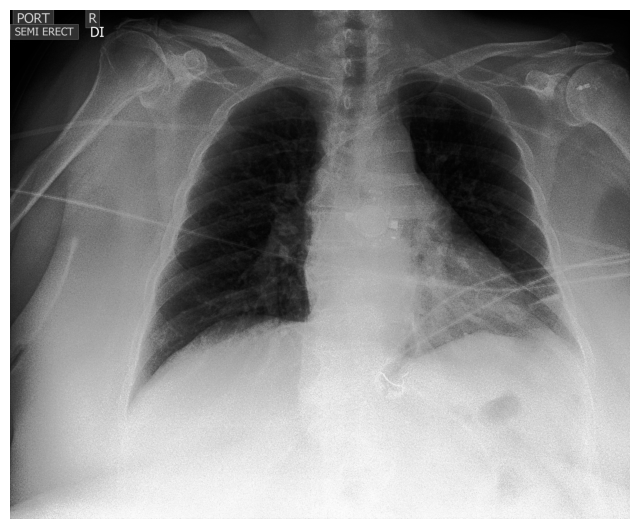

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [8]:
def csv_path_to_redivis_png(path: str) -> str:
    path = str(path)

    if path.startswith("train/"):
        path = path[len("train/"):]

    if path.endswith(".jpg"):
        path = path[:-4] + ".png"

    return path

In [9]:
test_csv_path = "train/patient00001/study1/view1_frontal.jpg"

test_png_path = csv_path_to_redivis_png(test_csv_path)

print("CSV path:    ", test_csv_path)
print("Redivis path:", test_png_path)

CSV path:     train/patient00001/study1/view1_frontal.jpg
Redivis path: patient00001/study1/view1_frontal.png


In [14]:
match = manifest[
    manifest["path_to_image"] == test_csv_path
]

print("Matching manifest rows:", len(match))

if len(match) == 1:
    print(
        match[
            [
                "sample_id",
                "path_to_image",
                "deid_patient_id",
                "frontal_lateral",
                "ap_pa",
                "experiment_split",
            ]
        ].to_string(index=False)
    )

Matching manifest rows: 1
 sample_id                               path_to_image deid_patient_id frontal_lateral ap_pa experiment_split
    219760 train/patient00001/study1/view1_frontal.jpg    patient00001         Frontal    AP            train


In [15]:
def csv_path_to_redivis_png(path: str) -> str:
    path = str(path)

    if path.startswith("train/"):
        path = path[len("train/"):]

    if path.endswith(".jpg"):
        path = path[:-4] + ".png"

    return path

In [16]:
test_csv_path = "train/patient00001/study1/view1_frontal.jpg"

test_png_path = csv_path_to_redivis_png(test_csv_path)

print("CSV path:    ", test_csv_path)
print("Redivis path:", test_png_path)

CSV path:     train/patient00001/study1/view1_frontal.jpg
Redivis path: patient00001/study1/view1_frontal.png


In [17]:
match = manifest[
    manifest["path_to_image"] == test_csv_path
]

print("Matching manifest rows:", len(match))

if len(match) == 1:
    print(
        match[
            [
                "sample_id",
                "path_to_image",
                "deid_patient_id",
                "frontal_lateral",
                "ap_pa",
                "experiment_split",
            ]
        ].to_string(index=False)
    )

Matching manifest rows: 1
 sample_id                               path_to_image deid_patient_id frontal_lateral ap_pa experiment_split
    219760 train/patient00001/study1/view1_frontal.jpg    patient00001         Frontal    AP            train


In [18]:
import pandas as pd

# Filter for frontal projections only
frontal = manifest[manifest["frontal_lateral"] == "Frontal"].copy()

# Sample 1 image per patient
patient_sample = (
    frontal
    .groupby("deid_patient_id", group_keys=False)
    .sample(n=1, random_state=42)
)

# Take 100 patient-unique samples
sample = (
    patient_sample
    .sample(n=100, random_state=42)
    .reset_index(drop=True)
)

# Apply your path conversion mapping function
sample["redivis_png_path"] = sample["path_to_image"].map(csv_path_to_redivis_png)

print("Sample rows:     ", len(sample))
print("Unique patients: ", sample["deid_patient_id"].nunique())

assert len(sample) == 100, f"Expected 100 samples, got {len(sample)}"
assert sample["deid_patient_id"].nunique() == 100, "Duplicate patients detected in validation slice!"

Sample rows:      100
Unique patients:  100


In [19]:
from pathlib import Path

SAMPLE_PATH = PROJECT_ROOT / "data" / "processed" / "image_validation_sample.parquet"
sample.to_parquet(SAMPLE_PATH, index=False)

print("Validation sample saved to:", SAMPLE_PATH)

Validation sample saved to: /content/drive/MyDrive/DP-MMFL/data/processed/image_validation_sample.parquet


In [20]:
from io import BytesIO
from PIL import Image
import time

results = []
start_time = time.time()

print("Beginning remote download and decoding of 100 images...")

for i, (_, row) in enumerate(sample.iterrows()):
    png_path = row["redivis_png_path"]

    try:
        # Access remote file descriptor via Redivis table
        file = table.file(png_path)
        data = file.read(as_text=False)

        # Decode image in-memory
        image = Image.open(BytesIO(data))
        image.load()

        results.append({
            "sample_id": row["sample_id"],
            "patient_id": row["deid_patient_id"],
            "path": row["path_to_image"],
            "redivis_path": png_path,
            "success": True,
            "bytes": len(data),
            "format": image.format,
            "mode": image.mode,
            "width": image.width,
            "height": image.height,
            "error": None,
        })

    except Exception as e:
        results.append({
            "sample_id": row["sample_id"],
            "patient_id": row["deid_patient_id"],
            "path": row["path_to_image"],
            "redivis_path": png_path,
            "success": False,
            "bytes": None,
            "format": None,
            "mode": None,
            "width": None,
            "height": None,
            "error": str(e),
        })

    if (i + 1) % 10 == 0:
        elapsed = time.time() - start_time
        print(f"Processed {i + 1}/100 images ({elapsed:.1f}s elapsed)")

print("Completed retrieval and decode loop.")

Beginning remote download and decoding of 100 images...
Processed 10/100 images (3.4s elapsed)
Processed 20/100 images (7.0s elapsed)
Processed 30/100 images (10.5s elapsed)
Processed 40/100 images (14.1s elapsed)
Processed 50/100 images (17.8s elapsed)
Processed 60/100 images (20.9s elapsed)
Processed 70/100 images (24.1s elapsed)
Processed 80/100 images (27.3s elapsed)
Processed 90/100 images (31.4s elapsed)
Processed 100/100 images (34.7s elapsed)
Completed retrieval and decode loop.


In [21]:
image_results = pd.DataFrame(results)

print("--- Retrieval Success Breakdown ---")
print(image_results["success"].value_counts(dropna=False))

print("\n--- Image Metric Distribution ---")
print(image_results[["bytes", "width", "height", "format", "mode"]].describe(include="all"))

failures = image_results[~image_results["success"]]
print(f"\nFailed images count: {len(failures)}")

if len(failures) > 0:
    print("Failure Details:")
    print(failures[["path", "redivis_path", "error"]].to_string(index=False))
else:
    print("All 100 images retrieved and decoded without error.")

--- Retrieval Success Breakdown ---
success
True    100
Name: count, dtype: int64

--- Image Metric Distribution ---
               bytes       width       height format mode
count   1.000000e+02   100.00000   100.000000    100  100
unique           NaN         NaN          NaN      1    1
top              NaN         NaN          NaN    PNG    L
freq             NaN         NaN          NaN    100  100
mean    3.529001e+06  2738.45000  2316.800000    NaN  NaN
std     1.292040e+06   462.75334   301.259142    NaN  NaN
min     1.623726e+06  1981.00000  1741.000000    NaN  NaN
25%     2.930524e+06  2744.50000  2252.000000    NaN  NaN
50%     3.503289e+06  2828.00000  2320.000000    NaN  NaN
75%     3.869980e+06  2828.00000  2320.000000    NaN  NaN
max     8.526732e+06  4240.00000  3480.000000    NaN  NaN

Failed images count: 0
All 100 images retrieved and decoded without error.


In [22]:
print("--- Image Formats ---")
print(image_results["format"].value_counts(dropna=False))

print("\n--- Color Modes ---")
print(image_results["mode"].value_counts(dropna=False))

print("\n--- Top 10 Most Common Dimensions (Width x Height) ---")
print(image_results[["width", "height"]].value_counts().head(10))

--- Image Formats ---
format
PNG    100
Name: count, dtype: int64

--- Color Modes ---
mode
L    100
Name: count, dtype: int64

--- Top 10 Most Common Dimensions (Width x Height) ---
width  height
2828   2320      61
3408   2800       7
2022   2022       5
2494   2048       4
2021   2021       4
2022   1746       2
4240   3480       2
2022   2016       2
1981   1891       1
2017   2007       1
Name: count, dtype: int64


In [23]:
size_mismatches = []

print("Running byte-for-byte metadata size check...")
for _, row in sample.iterrows():
    png_path = row["redivis_png_path"]
    try:
        file = table.file(png_path)
        expected_size = file.properties["size"]

        actual_size = image_results.loc[
            image_results["sample_id"] == row["sample_id"], "bytes"
        ].iloc[0]

        if expected_size != actual_size:
            size_mismatches.append({
                "sample_id": row["sample_id"],
                "expected": expected_size,
                "actual": actual_size,
            })
    except Exception as e:
        print(f"Metadata property read failed for {png_path}: {e}")

print(f"Total size mismatches found: {len(size_mismatches)}")
assert len(size_mismatches) == 0, f"Detected {len(size_mismatches)} corrupted downloads!"
print("All fetched byte buffers match remote metadata size exactly.")

Running byte-for-byte metadata size check...
Total size mismatches found: 0
All fetched byte buffers match remote metadata size exactly.


In [24]:
RESULT_PATH = PROJECT_ROOT / "data" / "processed" / "image_validation_results.parquet"
image_results.to_parquet(RESULT_PATH, index=False)

print("Validation results successfully persisted to:", RESULT_PATH)

Validation results successfully persisted to: /content/drive/MyDrive/DP-MMFL/data/processed/image_validation_results.parquet
